In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

# 1. Data Collection

In [2]:
now = datetime.now()
start = datetime(now.year-10, now.month, now.day)
end = now
ticker = 'AAPL'
df = yf.download(ticker, start, end)

C:\Users\hmtas\AppData\Local\Temp\ipykernel_16052\2586799446.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start, end)
[*********************100%***********************]  1 of 1 completed


In [3]:
df.tail(5)

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-07-15,209.110001,211.889999,208.919998,209.220001,42296300
2025-07-16,210.160004,212.399994,208.639999,210.300003,47490500
2025-07-17,210.020004,211.800003,209.589996,210.570007,48068100
2025-07-18,211.179993,211.789993,209.699997,210.869995,48974600
2025-07-21,212.479996,215.779999,211.630005,212.100006,51322500


# . Data Exploration & Visualization

In [4]:
type(df)
df.shape

(2514, 5)

In [5]:
df.isna().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [6]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2514.000000,2514.000000,2514.000000,2514.000000,2.514000e+03
mean,104.274445,105.320331,103.116669,104.172657,1.090226e+08
std,69.098226,69.773819,68.334812,69.019540,6.414156e+07
min,20.647459,20.951431,20.448619,20.569748,2.323470e+07
25%,39.423865,39.936335,38.953938,39.411211,6.622050e+07
50%,93.159439,93.996642,91.745084,93.122984,9.397505e+07
75%,164.806194,166.658286,163.586112,165.047842,1.325875e+08
max,258.396667,259.474086,257.010028,257.568678,6.488252e+08


In [7]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-07-22,28.045128,28.107838,27.321714,27.321714,461802400
2015-07-23,28.031696,28.463951,28.009298,28.264620,203998000
2015-07-24,27.883869,28.161588,27.749489,28.067522,168649200
2015-07-27,27.496408,27.684541,27.350831,27.568078,177822000
2015-07-28,27.633030,27.751734,27.447139,27.633030,134472400


In [8]:
df = df.reset_index()
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2015-07-22,28.045128,28.107838,27.321714,27.321714,461802400
1,2015-07-23,28.031696,28.463951,28.009298,28.264620,203998000
2,2015-07-24,27.883869,28.161588,27.749489,28.067522,168649200
3,2015-07-27,27.496408,27.684541,27.350831,27.568078,177822000
4,2015-07-28,27.633030,27.751734,27.447139,27.633030,134472400


Text(0, 0.5, 'Close Price')

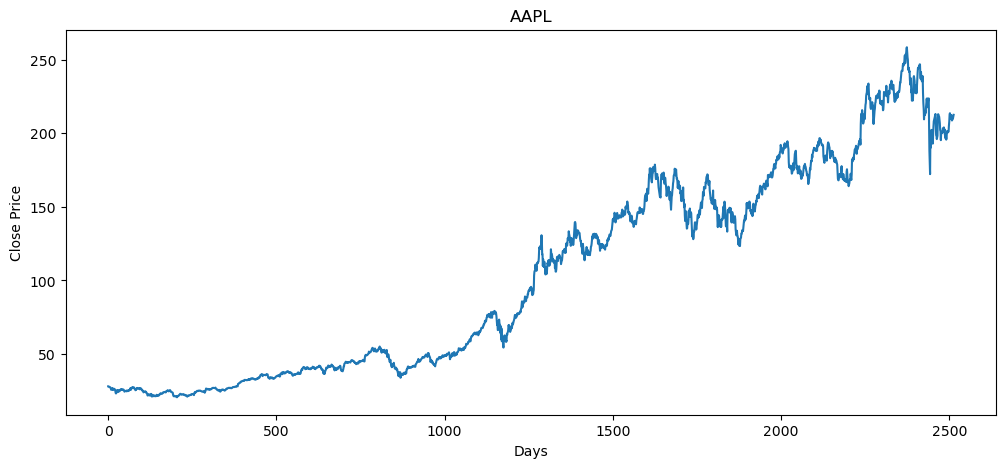

In [9]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.title(ticker)
plt.xlabel("Days")
plt.ylabel("Close Price")

# 100 Days Moving Average

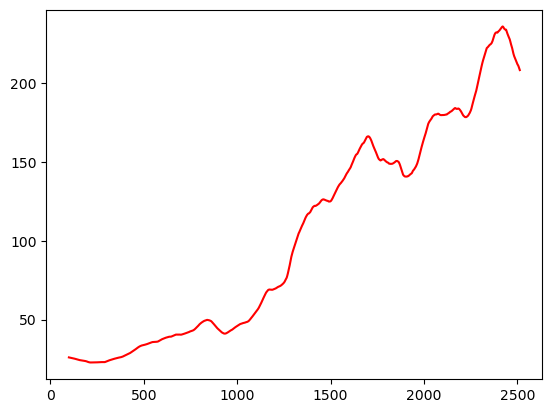

In [10]:
df['MA_100'] = df.Close.rolling(100).mean()
plt.plot(df['MA_100'], 'r')

Text(0, 0.5, 'Close Price')

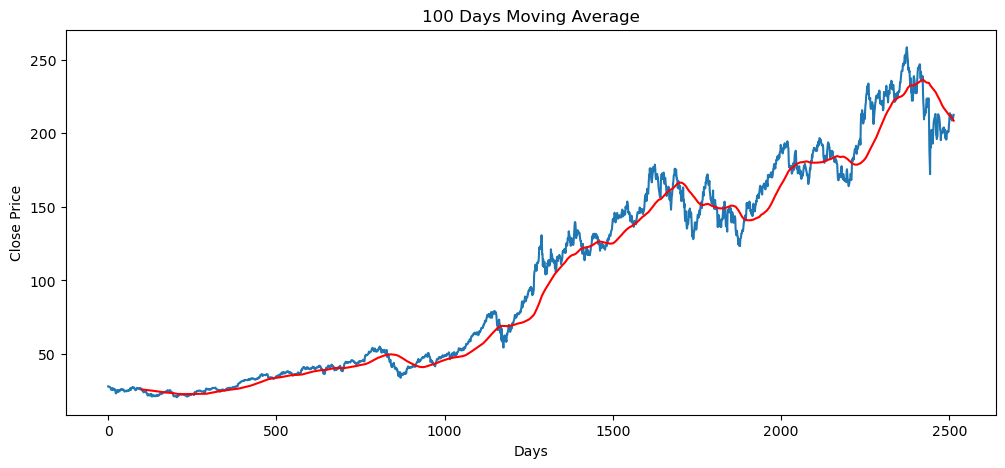

In [11]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.plot(df['MA_100'], 'r')
plt.title("100 Days Moving Average")
plt.xlabel("Days")
plt.ylabel("Close Price")

# 200 Days Moving Average

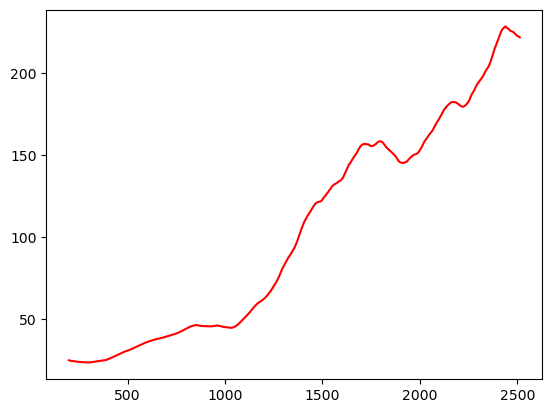

In [12]:
df['MA_200'] = df.Close.rolling(200).mean()
plt.plot(df['MA_200'], 'r')

Text(0, 0.5, 'Close Price')

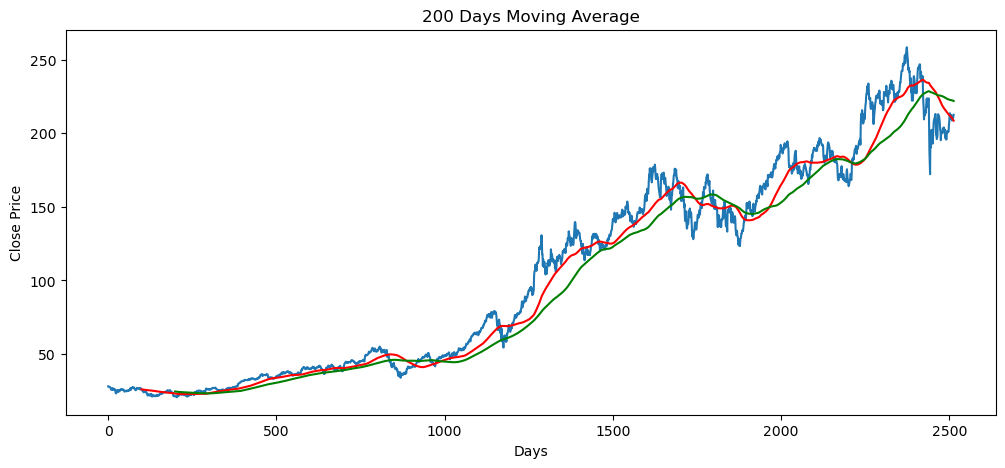

In [13]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.plot(df['MA_100'], 'r')
plt.plot(df['MA_200'], 'g')
plt.title("200 Days Moving Average")
plt.xlabel("Days")
plt.ylabel("Close Price")

### Calculate percentage chnaged in each day

In [14]:
df

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,
0,2015-07-22,28.045128,28.107838,27.321714,27.321714,461802400,NaN,NaN
1,2015-07-23,28.031696,28.463951,28.009298,28.264620,203998000,NaN,NaN
2,2015-07-24,27.883869,28.161588,27.749489,28.067522,168649200,NaN,NaN
3,2015-07-27,27.496408,27.684541,27.350831,27.568078,177822000,NaN,NaN
4,2015-07-28,27.633030,27.751734,27.447139,27.633030,134472400,NaN,NaN
...,...,...,...,...,...,...,...,...
2509,2025-07-15,209.110001,211.889999,208.919998,209.220001,42296300,209.931449,222.233988
2510,2025-07-16,210.160004,212.399994,208.639999,210.300003,47490500,209.577968,222.156903
2511,2025-07-17,210.020004,211.800003,209.589996,210.570007,48068100,209.225884,222.073388


In [15]:
df['Percentage Chnaged'] = df.Close.pct_change()
df[['Close','Percentage Chnaged']]

Price,Close,Percentage Chnaged
Ticker,AAPL,
0,28.045128,NaN
1,28.031696,-0.000479
2,27.883869,-0.005274
3,27.496408,-0.013896
4,27.633030,0.004969
...,...,...
2509,209.110001,0.002349
2510,210.160004,0.005021
2511,210.020004,-0.000666


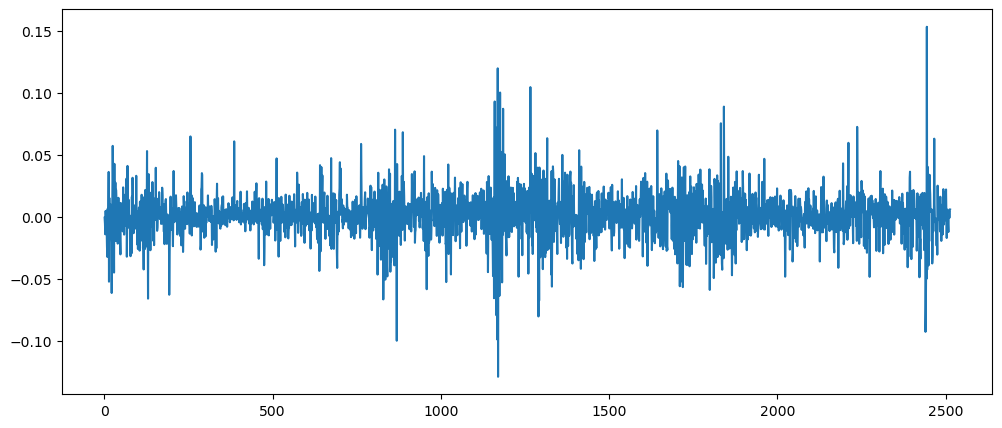

In [16]:
plt.figure(figsize=(12,5))
plt.plot(df['Percentage Chnaged'])

In [17]:
df

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200,Percentage Chnaged
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,,
0,2015-07-22,28.045128,28.107838,27.321714,27.321714,461802400,NaN,NaN,NaN
1,2015-07-23,28.031696,28.463951,28.009298,28.264620,203998000,NaN,NaN,-0.000479
2,2015-07-24,27.883869,28.161588,27.749489,28.067522,168649200,NaN,NaN,-0.005274
3,2015-07-27,27.496408,27.684541,27.350831,27.568078,177822000,NaN,NaN,-0.013896
4,2015-07-28,27.633030,27.751734,27.447139,27.633030,134472400,NaN,NaN,0.004969
...,...,...,...,...,...,...,...,...,...
2509,2025-07-15,209.110001,211.889999,208.919998,209.220001,42296300,209.931449,222.233988,0.002349
2510,2025-07-16,210.160004,212.399994,208.639999,210.300003,47490500,209.577968,222.156903,0.005021
2511,2025-07-17,210.020004,211.800003,209.589996,210.570007,48068100,209.225884,222.073388,-0.000666


In [18]:
df.shape

(2514, 9)

## Data Preprocessing

In [19]:
data_training = pd.DataFrame(df.Close[0:int(len(df)*0.7)])
data_testing = pd.DataFrame(df.Close[int(len(df)*0.7):len(df)])

print(data_training)
print(data_testing)

Ticker        AAPL
0        28.045128
1        28.031696
2        27.883869
3        27.496408
4        27.633030
...            ...
1754    142.582489
1755    143.556870
1756    143.192719
1757    146.125656
1758    147.798798

[1759 rows x 1 columns]
Ticker        AAPL
1759    144.747787
1760    148.615738
1761    150.623489
1762    152.897049
1763    151.656921
...            ...
2509    209.110001
2510    210.160004
2511    210.020004
2512    211.179993
2513    212.479996

[755 rows x 1 columns]


# Scalling down the data between 0 and 1

In [20]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [21]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.04682122],
       [0.04673621],
       [0.04580059],
       ...,
       [0.77561174],
       [0.79417485],
       [0.80476447]])

In [22]:
data_training_array.shape

(1759, 1)

In [23]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i,0])


In [24]:
x_train, y_train = np.array(x_train), np.array(y_train)

# 6. Building Model

In [25]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [26]:
# ML Model
from keras.models import Sequential
from keras.layers import Dense, LSTM, Input

In [27]:
model = Sequential()

model.add(Input(shape=(100,1)))
model.add(LSTM(units=128, activation='tanh', return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(25))
model.add(Dense(1))

# 7. Model Training

In [28]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 18s 161ms/step - loss: 0.0303
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 160ms/step - loss: 5.8181e-04
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 170ms/step - loss: 5.3436e-04
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 157ms/step - loss: 5.3467e-04
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 157ms/step - loss: 4.9823e-04
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 166ms/step - loss: 5.8419e-04
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 165ms/step - loss: 4.8243e-04
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 245ms/step - loss: 5.3733e-04
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 262ms/step - loss: 6.2035e-04
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 208ms/step - loss: 5.2443e-04
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 264ms/step - loss: 4.9369e-04
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 20s 251ms/step - loss: 3.6429e-04
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 232ms/step - loss: 3.5154e-04
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 136ms/step - loss: 3.6066

In [29]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [30]:
# Saving the trained model
model.save('stock_prediction_model.keras')

# 8. Preparing Test Data

In [31]:
data_testing

Ticker,AAPL
1759,144.747787
1760,148.615738
1761,150.623489
1762,152.897049
1763,151.656921
...,...
2509,209.110001
2510,210.160004
2511,210.020004
2512,211.179993


In [32]:
past_100_days = data_training.tail(100)

In [33]:
past_100_days

Ticker,AAPL
1659,161.488129
1660,157.311401
1661,159.935364
1662,162.009018
1663,162.274353
...,...
1754,142.582489
1755,143.556870
1756,143.192719
1757,146.125656


In [34]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)

In [35]:
final_df

Ticker,AAPL
0,161.488129
1,157.311401
2,159.935364
3,162.009018
4,162.274353
...,...
850,209.110001
851,210.160004
852,210.020004
853,211.179993


In [36]:
input_data = scaler.fit_transform(final_df)

In [37]:
input_data

array([[2.82028238e-01],
       [2.51083882e-01],
       [2.70524181e-01],
       [2.85887379e-01],
       [2.87853182e-01],
       [2.73873247e-01],
       [2.98337540e-01],
       [2.95934917e-01],
       [2.73655063e-01],
       [2.45477234e-01],
       [2.31934345e-01],
       [2.72053164e-01],
       [2.39797896e-01],
       [2.12202720e-01],
       [1.82277272e-01],
       [2.14823866e-01],
       [2.47588757e-01],
       [2.55088065e-01],
       [2.79552585e-01],
       [2.89746069e-01],
       [3.14793241e-01],
       [3.24913696e-01],
       [3.53018947e-01],
       [3.57751390e-01],
       [3.64158535e-01],
       [3.88622942e-01],
       [3.79958667e-01],
       [3.56950553e-01],
       [3.54766114e-01],
       [3.84836943e-01],
       [3.60227042e-01],
       [3.36709079e-01],
       [3.38966095e-01],
       [3.24040056e-01],
       [2.92440244e-01],
       [3.06347037e-01],
       [3.26297185e-01],
       [2.89090726e-01],
       [2.87488940e-01],
       [3.04454038e-01],


In [38]:
input_data.shape

(855, 1)

In [39]:
x_test =[]
y_test = []
for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i,0])

In [40]:
x_test

[array([[0.28202824],
        [0.25108388],
        [0.27052418],
        [0.28588738],
        [0.28785318],
        [0.27387325],
        [0.29833754],
        [0.29593492],
        [0.27365506],
        [0.24547723],
        [0.23193434],
        [0.27205316],
        [0.2397979 ],
        [0.21220272],
        [0.18227727],
        [0.21482387],
        [0.24758876],
        [0.25508807],
        [0.27955259],
        [0.28974607],
        [0.31479324],
        [0.3249137 ],
        [0.35301895],
        [0.35775139],
        [0.36415854],
        [0.38862294],
        [0.37995867],
        [0.35695055],
        [0.35476611],
        [0.38483694],
        [0.36022704],
        [0.33670908],
        [0.3389661 ],
        [0.32404006],
        [0.29244024],
        [0.30634704],
        [0.32629719],
        [0.28909073],
        [0.28748894],
        [0.30445404],
        [0.30321616],
        [0.29731841],
        [0.26360673],
        [0.27154365],
        [0.22727459],
        [0

In [41]:
y_test

[0.1580031266996158,
 0.18665982948419635,
 0.20153477110869855,
 0.218379020250292,
 0.2091912171597905,
 0.2008786367327402,
 0.19103469926628036,
 0.2288789790440584,
 0.23296240940139712,
 0.27058794003763853,
 0.26329607588910786,
 0.25235827966631197,
 0.29698423502633875,
 0.2946506847526422,
 0.2929715731251248,
 0.289466273573894,
 0.28983153376836723,
 0.32137583826988525,
 0.3158994224231322,
 0.3422590896485984,
 0.3502182799896312,
 0.3490500352203074,
 0.3601486996748382,
 0.35722820080018103,
 0.3380239480003333,
 0.3091816193292394,
 0.3066989578836117,
 0.30888938856393056,
 0.32714425878464337,
 0.2803390645608417,
 0.2639829594983987,
 0.24594717756517848,
 0.23360701281485596,
 0.23901028618379283,
 0.22331121988652392,
 0.213964696488675,
 0.22440666132398746,
 0.21345371658182932,
 0.2347022281550155,
 0.2789517315040253,
 0.20892657026555916,
 0.2196602006229207,
 0.19819271381089387,
 0.18599849487024778,
 0.21359966239150574,
 0.2312702971789049,
 0.20805033016

In [42]:
x_test, y_test = np.array(x_test), np.array(y_test)

In [43]:
x_test

array([[[0.28202824],
        [0.25108388],
        [0.27052418],
        ...,
        [0.146482  ],
        [0.16821142],
        [0.18060732]],

       [[0.25108388],
        [0.27052418],
        [0.28588738],
        ...,
        [0.16821142],
        [0.18060732],
        [0.15800313]],

       [[0.27052418],
        [0.28588738],
        [0.28785318],
        ...,
        [0.18060732],
        [0.15800313],
        [0.18665983]],

       ...,

       [[0.90243969],
        [0.91390825],
        [0.9134642 ],
        ...,
        [0.63121676],
        [0.63484709],
        [0.64262631]],

       [[0.91390825],
        [0.9134642 ],
        [0.86403853],
        ...,
        [0.63484709],
        [0.64262631],
        [0.64158908]],

       [[0.9134642 ],
        [0.86403853],
        [0.84139749],
        ...,
        [0.64262631],
        [0.64158908],
        [0.65018316]]])

# 9. Predic data

In [47]:
y_predict = model.predict(x_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step


In [49]:
y_predict

array([[0.16526006],
       [0.16556989],
       [0.17284697],
       [0.18481712],
       [0.19998997],
       [0.20730299],
       [0.2067094 ],
       [0.20053458],
       [0.20875396],
       [0.21951362],
       [0.24124752],
       [0.25516486],
       [0.25749215],
       [0.2729088 ],
       [0.2847665 ],
       [0.29042608],
       [0.29081562],
       [0.28983632],
       [0.3015219 ],
       [0.30964264],
       [0.32453048],
       [0.33834594],
       [0.34572074],
       [0.35302502],
       [0.3558903 ],
       [0.34840065],
       [0.3297529 ],
       [0.31546435],
       [0.30918664],
       [0.31515935],
       [0.30304068],
       [0.2853381 ],
       [0.2663501 ],
       [0.24989885],
       [0.24261689],
       [0.23466694],
       [0.22622228],
       [0.22467536],
       [0.22141403],
       [0.22672017],
       [0.2488801 ],
       [0.24065383],
       [0.23150687],
       [0.2172808 ],
       [0.20257623],
       [0.20313795],
       [0.21417934],
       [0.215

In [50]:
y_test

array([1.58003127e-01, 1.86659829e-01, 2.01534771e-01, 2.18379020e-01,
       2.09191217e-01, 2.00878637e-01, 1.91034699e-01, 2.28878979e-01,
       2.32962409e-01, 2.70587940e-01, 2.63296076e-01, 2.52358280e-01,
       2.96984235e-01, 2.94650685e-01, 2.92971573e-01, 2.89466274e-01,
       2.89831534e-01, 3.21375838e-01, 3.15899422e-01, 3.42259090e-01,
       3.50218280e-01, 3.49050035e-01, 3.60148700e-01, 3.57228201e-01,
       3.38023948e-01, 3.09181619e-01, 3.06698958e-01, 3.08889389e-01,
       3.27144259e-01, 2.80339065e-01, 2.63982959e-01, 2.45947178e-01,
       2.33607013e-01, 2.39010286e-01, 2.23311220e-01, 2.13964696e-01,
       2.24406661e-01, 2.13453717e-01, 2.34702228e-01, 2.78951732e-01,
       2.08926570e-01, 2.19660201e-01, 1.98192714e-01, 1.85998495e-01,
       2.13599662e-01, 2.31270297e-01, 2.08050330e-01, 2.00894350e-01,
       1.84027039e-01, 1.86509814e-01, 1.93738484e-01, 1.79718868e-01,
       1.25976783e-01, 9.47248221e-02, 1.25757694e-01, 1.52409705e-01,
      

In [51]:
y_predict = scaler.inverse_transform(y_predict.reshape(-1,1)).flatten()
y_test = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

In [52]:
y_predict

array([145.7273  , 145.76912 , 146.75134 , 148.36702 , 150.41498 ,
       151.40207 , 151.32193 , 150.48848 , 151.5979  , 153.05019 ,
       155.98373 , 157.86223 , 158.17636 , 160.25723 , 161.85773 ,
       162.62163 , 162.67421 , 162.54202 , 164.1193  , 165.2154  ,
       167.22488 , 169.08965 , 170.08505 , 171.07095 , 171.45769 ,
       170.44678 , 167.92978 , 166.00117 , 165.15385 , 165.96    ,
       164.3243  , 161.93489 , 159.37196 , 157.15146 , 156.16856 ,
       155.09552 , 153.95569 , 153.7469  , 153.3067  , 154.0229  ,
       157.01395 , 155.90361 , 154.66899 , 152.74883 , 150.76407 ,
       150.83989 , 152.3302  , 152.5347  , 151.97026 , 150.56728 ,
       149.5612  , 149.36903 , 148.80005 , 145.80696 , 141.81264 ,
       140.31291 , 141.24026 , 142.69662 , 143.49959 , 142.04784 ,
       140.52821 , 139.01166 , 137.79048 , 138.55014 , 138.17755 ,
       138.88338 , 140.11232 , 141.12067 , 141.5559  , 142.9435  ,
       144.86752 , 147.27481 , 147.93004 , 146.27338 , 148.309

In [53]:
y_test

array([144.74778748, 148.61573792, 150.62348938, 152.89704895,
       151.65692139, 150.53492737, 149.20623779, 154.31428528,
       154.865448  , 159.94396973, 158.95974731, 157.4834137 ,
       163.50682068, 163.19184875, 162.96520996, 162.49208069,
       162.54138184, 166.79908752, 166.05990601, 169.61781311,
       170.69210815, 170.53442383, 172.0324707 , 171.63827515,
       169.0461731 , 165.15316772, 164.81806946, 165.11372375,
       167.5776825 , 161.26013184, 159.05245972, 156.61807251,
       154.95245361, 155.6817627 , 153.56277466, 152.30122375,
       153.71063232, 152.23225403, 155.10028076, 161.07287598,
       151.62120056, 153.06997681, 150.1723938 , 148.526474  ,
       152.25195312, 154.63705444, 151.50292969, 150.53704834,
       148.26037598, 148.5954895 , 149.57118225, 147.67887878,
       140.42501831, 136.20677185, 140.39544678, 143.99281311,
       144.28848267, 143.33248901, 138.06951904, 138.39474487,
       136.97550964, 136.34475708, 140.9276886 , 136.38

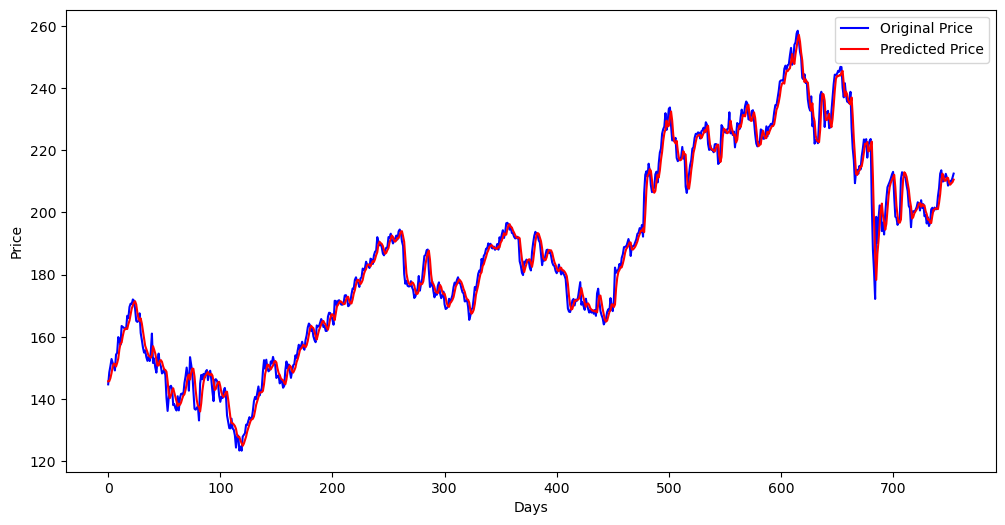

In [61]:
plt.figure(figsize=(12,6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predict, 'r', label='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()

(140.0, 260.0)

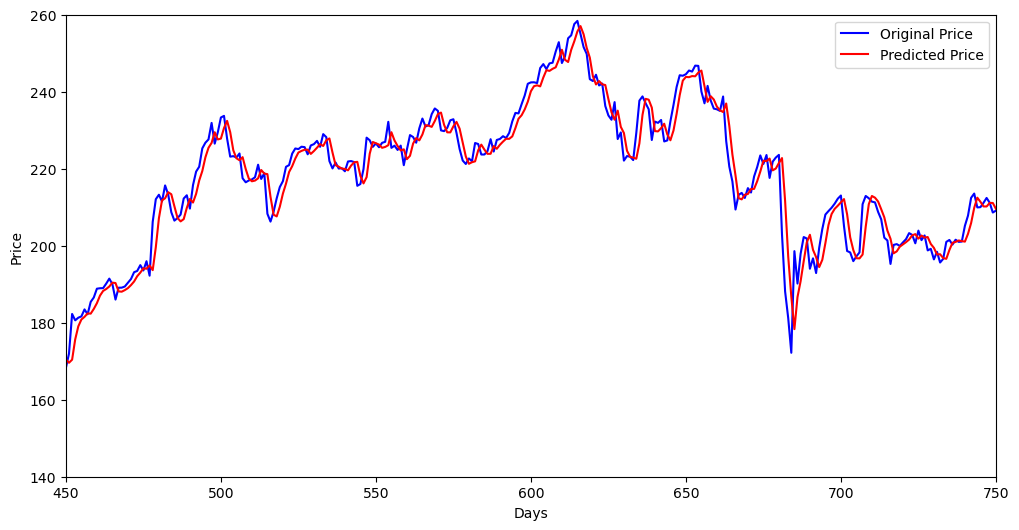

In [65]:
plt.figure(figsize=(12,6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predict, 'r', label='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.xlim(450,750)
plt.ylim(140,260)

# 10. Model Evaluation

In [70]:
# Mean Aquared Error (MSE)
from sklearn.metrics import mean_squared_error, r2_score

In [71]:
mse = mean_squared_error(y_test, y_predict)
print("Mean Aquared Error (MSE):", mse)

Mean Aquared Error (MSE): 13.860551102491966


In [72]:
rmse = np.sqrt(mse)
print("Root Mean Aquared Error (RMSE):", rmse)

Root Mean Aquared Error (RMSE): 3.7229761082354487


In [75]:
# R-squared
r2 = r2_score(y_test, y_predict)
print("R-squared:", r2)

R-squared: 0.9858081554524963
